# Mechanism follow-ups: branch separation and path validation

Цель — проверить две наиболее важные неопределённости после causal repair/transplant: какая ветвь Detect создаёт hiding и не является ли наблюдаемая нелинейность артефактом прямой в activation space. Target фиксируется до атаки; основной outcome — отсутствие person detection с IoU ≥ 0.5 и confidence ≥ 0.25.

## Уже проверенные и отвергнутые объяснения

- **Global winner promotion:** не объясняет исчезновение выбранного человека; visible target-winner и visible non-target-winner имеют почти одинаковый causal path.
- **Cross-scale reroute:** почти все target остаются на P5; большинство off-diagonal переходов относится к другому объекту, а не к тому же человеку.
- **Простое широкое распространение:** top-0.1% causal fraction почти одинаков для hidden и visible; различается амплитуда, а не ширина поддержки.
- **Sparse fixed-cell transplant:** сильно снижает logit, но не воспроизводит object hiding.
- **Статический clean candidate set:** подавление его score также почти не воспроизводит hiding; при сильной интервенции появляется handoff за пределы set.

Эти отрицательные результаты оставлены здесь, потому что именно они мотивируют branch-factorial и проверку реального opacity-path.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'CandidateRoutingAndAttackPath' else Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path: sys.path.insert(0, str(REPO_ROOT))
sns.set_theme(style='whitegrid', context='notebook')
print(REPO_ROOT)

/Users/ashentide/PycharmProjects/PatchSuccessResearch


## Загрузка результатов

Вычисление вынесено в `run_followup_experiments.py`. Этот ноутбук только читает последний завершённый run и строит графики. Расширенный запуск: `conda run -n IAD python -m CandidateRoutingAndAttackPath.run_followup_experiments mechanism --device mps`.

In [2]:
candidates = sorted((p.parent for p in (REPO_ROOT/'CandidateRoutingAndAttackPath'/'followup_outputs').glob('mechanism_*/summary.json')), key=lambda p: p.stat().st_mtime)
run_dir = candidates[-1]
print(run_dir)
summary = json.loads((run_dir/'summary.json').read_text())
display(summary)

/Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/followup_outputs/mechanism_db582b45847a0e71


{'status': 'complete',
 'elapsed_seconds': 276.3634250164032,
 'branch_examples': 400,
 'path_examples': 400,
 'hidden_reproduction_mean': {'both_patched': 0.9650000000000001,
  'box_only_patched': 0.185,
  'class_only_patched': 0.69,
  'clean': 0.0},
 'normalized_path_nonlinearity': {'activation_linear': {'hidden_low_conf_match': 0.17384463481368279,
   'hidden_no_iou_match': 0.20645438488065293,
   'visible_non_target_winner': 0.15133181075756968,
   'visible_target_winner': 0.20348643561751772},
  'image_opacity': {'hidden_low_conf_match': 0.35999240646677905,
   'hidden_no_iou_match': 0.5027402038764588,
   'visible_non_target_winner': 0.5431210986458301,
   'visible_target_winner': 0.46158234480864946}},
 'cache_path': '/Users/ashentide/PycharmProjects/PatchSuccessResearch/new_experiments/new_experiments/outputs/patch_success_analysis/cache/attack_pool_d60ec9ed15ee6591.pkl',
 'config': {'output_dir': '/Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackP

In [3]:
branch = pd.read_csv(run_dir/'branch_factorial_summary.csv')
path_detail = pd.read_csv(run_dir/'path_detail.csv')
path_examples = pd.read_csv(run_dir/'path_example_summary.csv')
display(branch)

,analysis_group,condition,n,target_hidden_rate,pre_hidden_rate,nms_only_hidden_rate,mean_fixed_logit_loss,mean_fixed_iou_loss,mean_post_conf,mean_post_max_iou
0,hidden_low_conf_match,both_patched,100,1.00,0.99,0.01,6.424080,0.270795,0.112753,0.756444
1,hidden_low_conf_match,box_only_patched,100,0.01,0.01,0.00,0.000000,0.270795,0.888941,0.801922
2,hidden_low_conf_match,class_only_patched,100,0.85,0.85,0.00,6.424080,0.000000,0.184036,0.962715
3,hidden_low_conf_match,clean,100,0.00,0.00,0.00,0.000000,0.000000,0.903955,1.000000
4,hidden_no_iou_match,both_patched,100,0.93,0.83,0.10,7.666877,0.432340,0.041388,0.419169
5,hidden_no_iou_match,box_only_patched,100,0.36,0.18,0.18,0.000000,0.432340,0.572793,0.631573
6,hidden_no_iou_match,class_only_patched,100,0.53,0.53,0.00,7.666877,0.000000,0.298457,0.781921
7,hidden_no_iou_match,clean,100,0.00,0.00,0.00,0.000000,0.000000,0.903856,1.000000
8,visible_non_target_winner,both_patched,100,0.00,0.00,0.00,3.367701,0.155203,0.548956,0.869777
9,visible_non_target_winner,box_only_patched,100,0.01,0.00,0.01,0.000000,0.155203,0.894690,0.894557


## 1. Classification × geometry

`class_only_patched` берёт clean box/DFL outputs и patched class outputs. `box_only_patched` делает обратное. `both_patched` обязан воспроизвести обычный patched endpoint и служит sanity check.

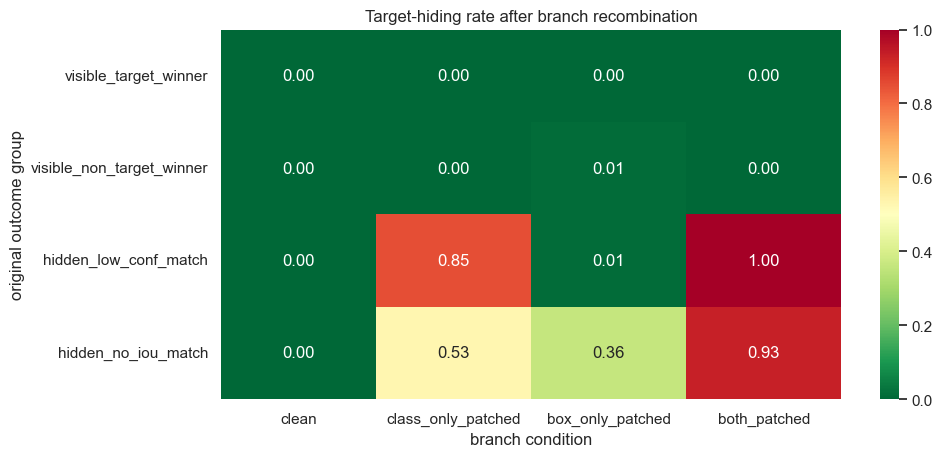

In [4]:
order = ['visible_target_winner','visible_non_target_winner','hidden_low_conf_match','hidden_no_iou_match']
conditions = ['clean','class_only_patched','box_only_patched','both_patched']
matrix = branch.pivot(index='analysis_group', columns='condition', values='target_hidden_rate').reindex(index=order, columns=conditions)
plt.figure(figsize=(10, 4.8))
sns.heatmap(matrix, annot=True, fmt='.2f', vmin=0, vmax=1, cmap='RdYlGn_r')
plt.title('Target-hiding rate after branch recombination')
plt.xlabel('branch condition'); plt.ylabel('original outcome group'); plt.show()

На 100 примерах каждой группы low-confidence failure почти полностью относится к classification-ветви: `class_only_patched` скрывает 85%, `box_only_patched` — 1%, обе ветви — 100%. No-IoU является смешанным режимом: class-only скрывает 53%, box-only — 36%, обе ветви — 93%. Среди 93 воспроизводимых no-IoU endpoints 57% скрываются class-only, 39% box-only, а 19% не скрываются ни одной ветвью отдельно и требуют их совместного действия. Одиночные ветви почти никогда не индуцируют hiding в visible controls (0–1%). Важно: 7/100 no-IoU labels не воспроизвелись даже в `both_patched`; их нельзя использовать как branch evidence без отдельного аудита расхождения стандартного prediction pipeline и ручного decode/NMS.

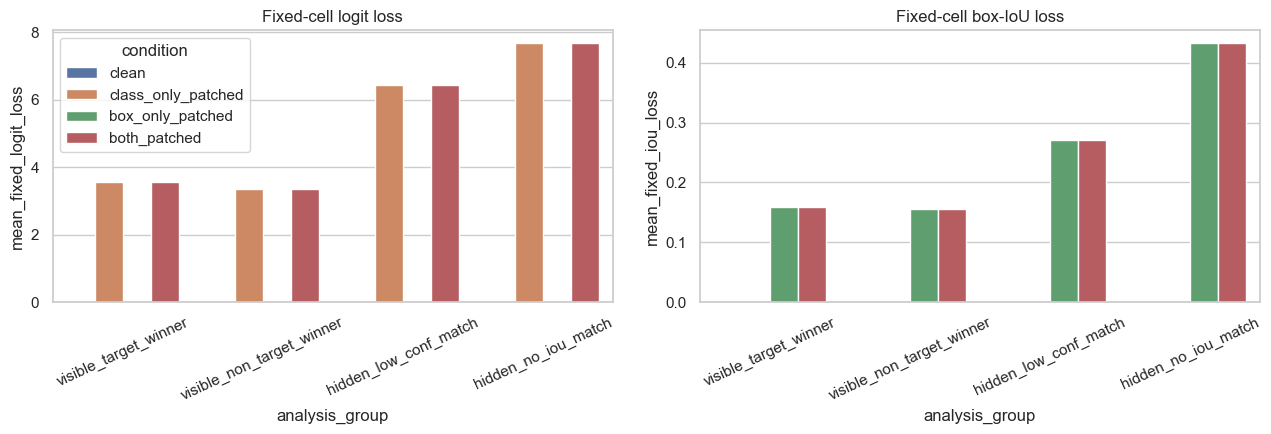

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=branch, x='analysis_group', y='mean_fixed_logit_loss', hue='condition', order=order, hue_order=conditions, ax=axes[0])
sns.barplot(data=branch, x='analysis_group', y='mean_fixed_iou_loss', hue='condition', order=order, hue_order=conditions, ax=axes[1])
axes[0].set_title('Fixed-cell logit loss'); axes[1].set_title('Fixed-cell box-IoU loss')
for ax in axes: ax.tick_params(axis='x', rotation=25)
axes[1].legend_.remove(); plt.tight_layout(); plt.show()

Endpoint controls сработали как задумано: class-only воспроизводит весь fixed-logit loss и сохраняет fixed IoU, box-only воспроизводит fixed-IoU loss и не меняет fixed logit. Для low-confidence class-only снижает post-target confidence примерно с 0.90 до 0.18 при IoU 0.96. Для no-IoU обе одиночные ветви уже ухудшают ensemble-output, но полное patched состояние сильнее каждой из них. Это подтверждает branch interaction на уровне candidate ensemble, а не ошибку смешивания ветвей.

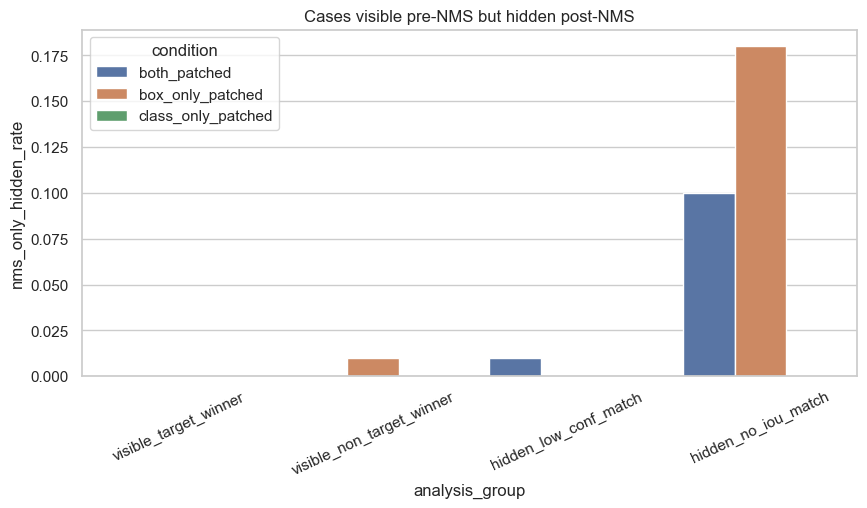

In [6]:
nms = branch[branch.condition.isin(['class_only_patched','box_only_patched','both_patched'])]
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(data=nms, x='analysis_group', y='nms_only_hidden_rate', hue='condition', order=order, ax=ax)
ax.set_title('Cases visible pre-NMS but hidden post-NMS'); ax.tick_params(axis='x', rotation=25); plt.show()

NMS почти не участвует в low-confidence failure: NMS-only contribution равен 1% для полного patched endpoint и 0% для одиночных ветвей. Для no-IoU он заметнее: 10% при обеих patched-ветвях и 18% при box-only. Тем не менее 83% полных no-IoU failures уже сформированы до NMS, поэтому NMS — вторичный усилитель geometry failure, а не общий первичный механизм.

## 2. Реальный opacity-path против прямой в activation space

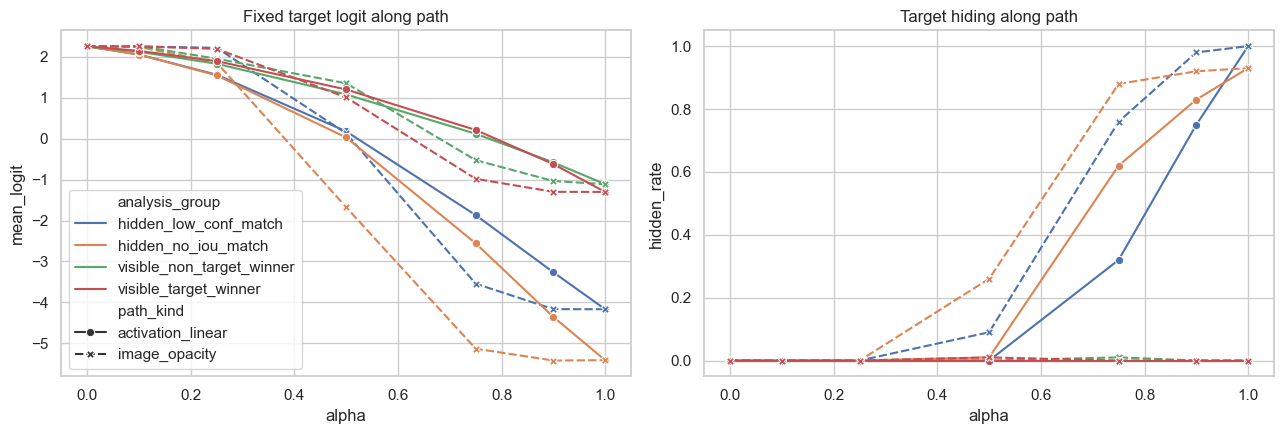

In [7]:
curve = path_detail.groupby(['analysis_group','path_kind','alpha'], as_index=False).agg(mean_logit=('fixed_target_logit','mean'), hidden_rate=('target_hidden','mean'))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.lineplot(data=curve, x='alpha', y='mean_logit', hue='analysis_group', style='path_kind', markers=True, ax=axes[0])
sns.lineplot(data=curve, x='alpha', y='hidden_rate', hue='analysis_group', style='path_kind', markers=True, ax=axes[1])
axes[0].set_title('Fixed target logit along path'); axes[1].set_title('Target hiding along path')
axes[1].legend_.remove(); plt.tight_layout(); plt.show()

Реальный `image_opacity` path существенно сильнее отклоняется от хорды, чем искусственный `activation_linear` path во всех группах. Значит прямая между clean/patched Detect inputs не воспроизводит то, как эффект патча возникает при изменении его прозрачности. Attribution вдоль этой прямой остаётся корректной декомпозицией выбранного пути, но её нельзя интерпретировать как временную или физическую траекторию усиления патча.

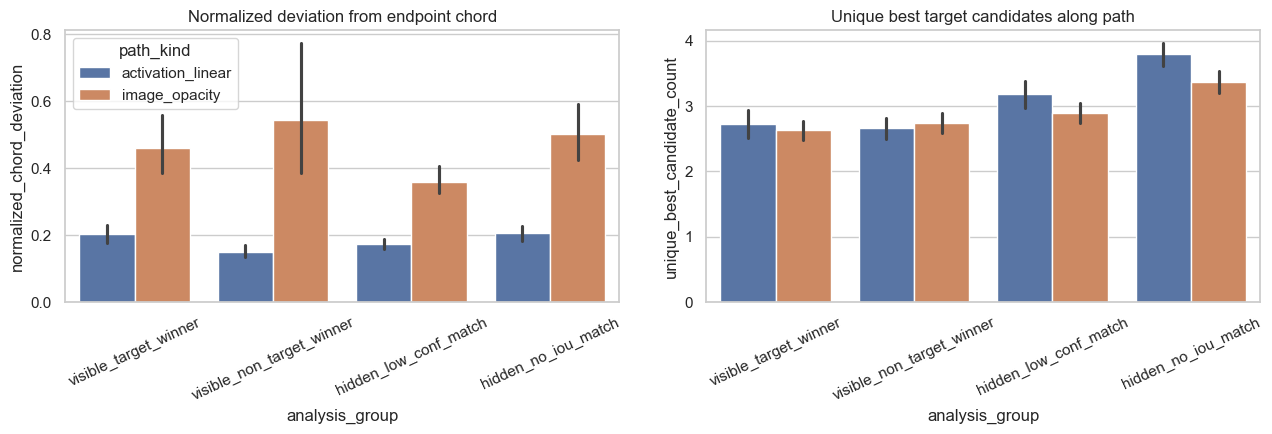

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=path_examples, x='analysis_group', y='normalized_chord_deviation', hue='path_kind', order=order, ax=axes[0])
sns.barplot(data=path_examples, x='analysis_group', y='unique_best_candidate_count', hue='path_kind', order=order, ax=axes[1])
axes[0].set_title('Normalized deviation from endpoint chord'); axes[1].set_title('Unique best target candidates along path')
for ax in axes: ax.tick_params(axis='x', rotation=25)
axes[1].legend_.remove(); plt.tight_layout(); plt.show()

Нормированная opacity-нелинейность не специфична для успешных атак: hidden low-confidence = 0.36, hidden no-IoU = 0.50, visible non-target = 0.54, visible target = 0.46; доверительные интервалы широко перекрываются. Смена best candidate также почти универсальна (93–100% на opacity-path), хотя no-IoU использует несколько больше уникальных кандидатов. Поэтому route instability — нормальное свойство перехода clean→patched, а не достаточное объяснение hiding; различающим фактором остаются endpoint magnitude и branch coordination.

In [ ]:
hidden = branch[branch.analysis_group.str.startswith('hidden')]
repro = hidden.groupby('condition').target_hidden_rate.mean().sort_values(ascending=False)
display(repro.to_frame('mean hidden reproduction'))
display(path_examples.groupby(['analysis_group','path_kind'])[['normalized_chord_deviation','unique_best_candidate_count']].mean())
display(Markdown('**Автоматическая сводка:** dominant single branch = `%s`; полный численный вывод и решение о следующем эксперименте следует закрепить после проверки confidence intervals и individual examples.' % repro.drop(labels=['both_patched','clean'], errors='ignore').idxmax()))

,mean hidden reproduction
condition,
both_patched,0.965
class_only_patched,0.690
box_only_patched,0.185
clean,0.000


normalized_chord_deviation  \
analysis_group            path_kind                                       
hidden_low_conf_match     activation_linear                    0.173845   
                          image_opacity                        0.359992   
hidden_no_iou_match       activation_linear                    0.206454   
                          image_opacity                        0.502740   
visible_non_target_winner activation_linear                    0.151332   
                          image_opacity                        0.543121   
visible_target_winner     activation_linear                    0.203486   
                          image_opacity                        0.461582   

                                             unique_best_candidate_count  
analysis_group            path_kind                                       
hidden_low_conf_match     activation_linear                         3.18  
                          image_opacity                             2.89  
hidden_no_iou_match       activation_linear                         3.79  
                          image_opacity                             3.37  
visible_non_target_winner activation_linear                         2.66  
                          image_opacity                             2.74  
visible_target_winner     activation_linear                         2.72  
                          image_opacity                             2.63

**Автоматическая сводка:** dominant single branch = `class_only_patched`; полный численный вывод и решение о следующем эксперименте следует закрепить после проверки confidence intervals и individual examples.

: 